<a href="https://colab.research.google.com/github/anushka903636/Meeting-notes-ai/blob/main/MAJOR_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# SMART AGRICULTURE PLATFORM


# @title 1. Setup and Installation


print("=" * 60)
print("SMART AGRICULTURE PLATFORM - SETUP")
print("=" * 60)

!pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn pillow opencv-python flask-ngrok pyngrok joblib gradio

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
import os
import cv2
from PIL import Image
import io
import base64
from datetime import datetime
import random

warnings.filterwarnings('ignore')

print("\n✅ Setup Complete!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

!mkdir -p datasets
!mkdir -p models
!mkdir -p static/uploads

print("📁 Directories created successfully!")

SMART AGRICULTURE PLATFORM - SETUP

✅ Setup Complete!
TensorFlow version: 2.19.0
GPU Available: []
📁 Directories created successfully!


In [2]:
# @title 2. Create Synthetic Dataset

print("=" * 60)
print("CREATING SYNTHETIC DATASET")
print("=" * 60)

np.random.seed(42)
n_samples = 2000

crops = ['rice', 'wheat', 'maize', 'cotton', 'sugarcane', 'groundnut',
         'pulses', 'vegetables', 'fruits', 'oilseeds']

data = []
for _ in range(n_samples):
    crop = random.choice(crops)

    if crop == 'rice':
        N = random.randint(60, 120)
        P = random.randint(30, 60)
        K = random.randint(30, 60)
        temp = random.uniform(20, 30)
        humidity = random.uniform(70, 90)
        pH = random.uniform(5.5, 7.0)
        rainfall = random.uniform(150, 250)
    elif crop == 'wheat':
        N = random.randint(70, 130)
        P = random.randint(35, 65)
        K = random.randint(35, 65)
        temp = random.uniform(15, 25)
        humidity = random.uniform(60, 80)
        pH = random.uniform(6.0, 7.5)
        rainfall = random.uniform(100, 200)
    elif crop == 'maize':
        N = random.randint(80, 150)
        P = random.randint(40, 70)
        K = random.randint(40, 70)
        temp = random.uniform(20, 30)
        humidity = random.uniform(65, 85)
        pH = random.uniform(5.8, 7.2)
        rainfall = random.uniform(120, 220)
    else:
        N = random.randint(40, 160)
        P = random.randint(20, 80)
        K = random.randint(20, 80)
        temp = random.uniform(15, 35)
        humidity = random.uniform(50, 90)
        pH = random.uniform(5.0, 8.0)
        rainfall = random.uniform(50, 300)

    data.append([N, P, K, temp, humidity, pH, rainfall, crop])

crop_df = pd.DataFrame(data, columns=['N', 'P', 'K', 'temperature',
                                      'humidity', 'ph', 'rainfall', 'label'])

crop_df.to_csv('datasets/crop_data.csv', index=False)

print(f"\n✅ Created Crop Dataset with {len(crop_df)} samples")
print(f"Shape: {crop_df.shape}")
print(f"\nFirst 5 rows:")
print(crop_df.head())

print("\n📊 Crop Distribution:")
print(crop_df['label'].value_counts())

print("\n🌱 Creating Sample Plant Disease Dataset...")

!mkdir -p datasets/plant_disease/train/healthy
!mkdir -p datasets/plant_disease/train/diseased
!mkdir -p datasets/plant_disease/validation/healthy
!mkdir -p datasets/plant_disease/validation/diseased

def create_sample_images():
    for category in ['healthy', 'diseased']:
        for split in ['train', 'validation']:
            path = f'datasets/plant_disease/{split}/{category}'
            n_samples = 50 if split == 'train' else 20
            for i in range(n_samples):

                if category == 'healthy':
                    img = np.random.randint(100, 200, (224, 224, 3), dtype=np.uint8)
                else:

                    img = np.random.randint(80, 180, (224, 224, 3), dtype=np.uint8)
                    for _ in range(random.randint(5, 15)):
                        x, y = random.randint(0, 200), random.randint(0, 200)
                        cv2.circle(img, (x, y), random.randint(5, 20),
                                  (0, random.randint(0, 255), 0), -1)

                cv2.imwrite(f'{path}/sample_{i}.jpg', img)

    print("✅ Sample images created!")

create_sample_images()

print("\n📁 Dataset Structure:")
!ls -la datasets/plant_disease/train/

CREATING SYNTHETIC DATASET

✅ Created Crop Dataset with 2000 samples
Shape: (2000, 8)

First 5 rows:
     N   P   K  temperature   humidity        ph    rainfall       label
0   43  55  69    16.564682  64.735019  5.786304  102.725691      pulses
1   41  73  29    32.945624  63.127608  6.221189  237.801903    oilseeds
2   84  54  43    31.471092  84.476844  7.809407   77.914674      fruits
3  151  64  70    28.671440  67.126703  6.286154  178.468511      pulses
4  151  39  76    25.441906  81.103861  5.140452  279.402835  vegetables

📊 Crop Distribution:
label
oilseeds      225
wheat         220
pulses        213
groundnut     202
cotton        198
vegetables    197
fruits        192
maize         188
rice          188
sugarcane     177
Name: count, dtype: int64

🌱 Creating Sample Plant Disease Dataset...
✅ Sample images created!

📁 Dataset Structure:
total 16
drwxr-xr-x 4 root root 4096 Mar 19 10:33 .
drwxr-xr-x 4 root root 4096 Mar 19 10:33 ..
drwxr-xr-x 2 root root 4096 Mar 19 10:33

CROP RECOMMENDATION MODEL

🚀 Starting training...
Loading and preprocessing data...

📊 Dataset Info:
Training samples: 1600
Test samples: 400
Number of crops: 10

🔄 Training individual models...
  Training Random Forest...
    ✓ Accuracy: 0.3775
  Training SVM...
    ✓ Accuracy: 0.3600
  Training Naive Bayes...
    ✓ Accuracy: 0.3825
  Training KNN...
    ✓ Accuracy: 0.3100

🔄 Making ensemble predictions...

🎯 Ensemble Model Accuracy: 0.3425


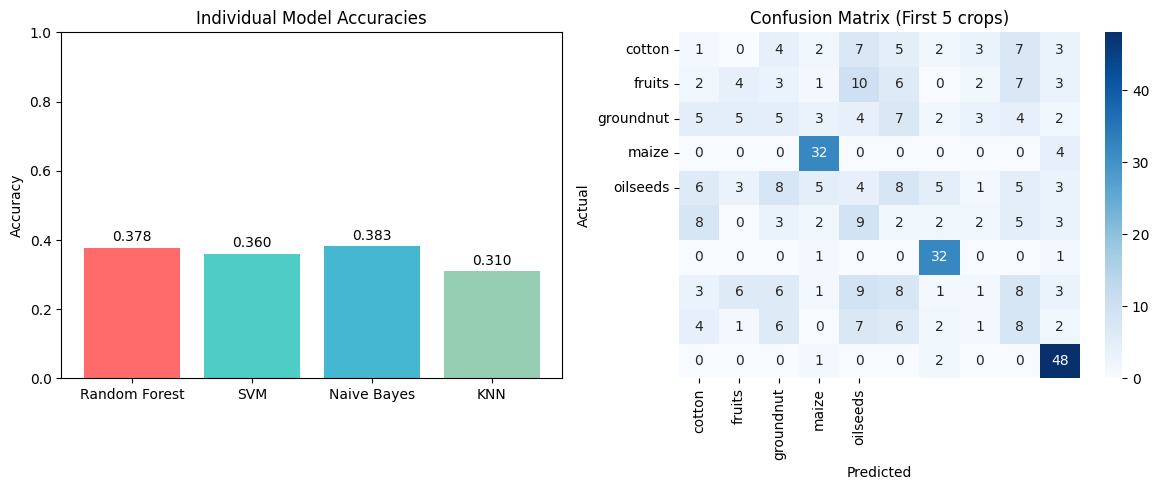


📊 Classification Report:
              precision    recall  f1-score   support

      cotton       0.03      0.03      0.03        34
      fruits       0.21      0.11      0.14        38
   groundnut       0.14      0.12      0.13        40
       maize       0.67      0.89      0.76        36
    oilseeds       0.08      0.08      0.08        48
      pulses       0.05      0.06      0.05        36
        rice       0.67      0.94      0.78        34
   sugarcane       0.08      0.02      0.03        46
  vegetables       0.18      0.22      0.20        37
       wheat       0.67      0.94      0.78        51

    accuracy                           0.34       400
   macro avg       0.28      0.34      0.30       400
weighted avg       0.28      0.34      0.30       400


✅ Model saved to 'models/' directory

🔍 Testing Prediction:

Input: N=90, P=42, K=43, Temp=22.5°C, Humidity=80%, pH=6.5, Rainfall=200mm

🎯 Primary Recommendation: rice (76.44%)

📋 Top 3 Recommendations:
  • rice: 7

In [3]:
# @title 3. Crop Recommendation Model (Ensemble Learning)

print("=" * 60)
print("CROP RECOMMENDATION MODEL")
print("=" * 60)

class CropRecommendationModel:
    def __init__(self):
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.models = {
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'SVM': SVC(kernel='rbf', probability=True, random_state=42),
            'Naive Bayes': GaussianNB(),
            'KNN': KNeighborsClassifier(n_neighbors=5)
        }
        self.ensemble_weights = None
        self.classes_ = None

    def train(self, filepath):
        print("Loading and preprocessing data...")
        df = pd.read_csv(filepath)

        features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
        X = df[features].values
        y = df['label'].values

        y_encoded = self.label_encoder.fit_transform(y)
        self.classes_ = self.label_encoder.classes_

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42
        )

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        print(f"\n📊 Dataset Info:")
        print(f"Training samples: {X_train.shape[0]}")
        print(f"Test samples: {X_test.shape[0]}")
        print(f"Number of crops: {len(self.classes_)}")

        print("\n🔄 Training individual models...")
        accuracies = []

        plt.figure(figsize=(12, 5))

        for name, model in self.models.items():
            print(f"  Training {name}...")
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            acc = accuracy_score(y_test, y_pred)
            accuracies.append(acc)
            print(f"    ✓ Accuracy: {acc:.4f}")

        total_acc = sum(accuracies)
        self.ensemble_weights = [acc/total_acc for acc in accuracies]


        plt.subplot(1, 2, 1)
        bars = plt.bar(self.models.keys(), accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
        plt.title('Individual Model Accuracies')
        plt.ylabel('Accuracy')
        plt.ylim(0, 1)
        for bar, acc in zip(bars, accuracies):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom')

        print("\n🔄 Making ensemble predictions...")
        ensemble_pred = self.ensemble_predict(X_test_scaled)
        ensemble_acc = accuracy_score(y_test, ensemble_pred)

        print(f"\n🎯 Ensemble Model Accuracy: {ensemble_acc:.4f}")


        plt.subplot(1, 2, 2)
        cm = confusion_matrix(y_test, ensemble_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.classes_[:5], yticklabels=self.classes_[:5])
        plt.title('Confusion Matrix (First 5 crops)')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

        plt.tight_layout()
        plt.show()


        print("\n📊 Classification Report:")
        print(classification_report(y_test, ensemble_pred,
                                  target_names=self.classes_, zero_division=0))

        return ensemble_acc

    def ensemble_predict(self, X):
        """Make predictions using weighted voting"""
        all_probs = []

        for name, model in self.models.items():
            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(X)
            else:
                pred = model.predict(X)
                probs = np.zeros((X.shape[0], len(self.classes_)))
                for i, p in enumerate(pred):
                    probs[i, p] = 1
            all_probs.append(probs)

        final_probs = np.zeros_like(all_probs[0])
        for i, probs in enumerate(all_probs):
            final_probs += probs * self.ensemble_weights[i]

        return np.argmax(final_probs, axis=1)

    def predict(self, features):
        """Predict crop for new features"""
        features_scaled = self.scaler.transform([features])

        all_probs = []
        for name, model in self.models.items():
            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(features_scaled)
            else:
                pred = model.predict(features_scaled)
                probs = np.zeros((1, len(self.classes_)))
                probs[0, pred[0]] = 1
            all_probs.append(probs[0])

        final_probs = np.zeros(len(self.classes_))
        for i, probs in enumerate(all_probs):
            final_probs += probs * self.ensemble_weights[i]

        top_3_idx = np.argsort(final_probs)[-3:][::-1]

        result = {
            'primary_crop': self.classes_[top_3_idx[0]],
            'primary_confidence': f"{final_probs[top_3_idx[0]]*100:.2f}%",
            'top_3': [
                {'crop': self.classes_[idx],
                 'confidence': f"{final_probs[idx]*100:.2f}%"}
                for idx in top_3_idx
            ]
        }

        return result

    def save_model(self):
        """Save model"""
        joblib.dump(self.scaler, 'models/crop_scaler.pkl')
        joblib.dump(self.label_encoder, 'models/crop_encoder.pkl')
        joblib.dump(self.models, 'models/crop_models.pkl')
        joblib.dump(self.ensemble_weights, 'models/crop_weights.pkl')
        joblib.dump(self.classes_, 'models/crop_classes.pkl')
        print("\n✅ Model saved to 'models/' directory")

# Train the model
print("\n🚀 Starting training...")
crop_model = CropRecommendationModel()
crop_model.train('datasets/crop_data.csv')
crop_model.save_model()

# Test prediction
print("\n🔍 Testing Prediction:")
test_features = [90, 42, 43, 22.5, 80.0, 6.5, 200.0]  # N, P, K, temp, humidity, pH, rainfall
result = crop_model.predict(test_features)
print(f"\nInput: N=90, P=42, K=43, Temp=22.5°C, Humidity=80%, pH=6.5, Rainfall=200mm")
print(f"\n🎯 Primary Recommendation: {result['primary_crop']} ({result['primary_confidence']})")
print("\n📋 Top 3 Recommendations:")
for rec in result['top_3']:
    print(f"  • {rec['crop']}: {rec['confidence']}")

FERTILIZER RECOMMENDATION SYSTEM
Testing Fertilizer Recommendations:


Crop: RICE
Current NPK: N=60, P=30, K=20

📊 Status:
  N: low
  P: low
  K: low

💡 Recommendations:
  • Nitrogen Deficiency
    Your soil needs more nitrogen
    Fertilizers: Urea (46-0-0) - 50 kg/acre, Ammonium Sulfate - 70 kg/acre
  • Phosphorus Deficiency
    Your soil needs more phosphorus
    Fertilizers: Single Super Phosphate (16% P) - 60 kg/acre, DAP (18-46-0) - 40 kg/acre

Crop: WHEAT
Current NPK: N=100, P=50, K=45

📊 Status:
  N: optimal
  P: optimal
  K: optimal

💡 Recommendations:
  • Balanced Nutrition
    Your soil has balanced nutrients
    Fertilizers: 10-26-26 Complex - 50 kg/acre, 12-32-16 Complex - 45 kg/acre

Crop: MAIZE
Current NPK: N=180, P=90, K=100

📊 Status:
  N: high
  P: high
  K: high

💡 Recommendations:
  • Excess Nitrogen
    Nitrogen levels are too high
    Fertilizers: Reduce nitrogen application, Use nitrogen-fixing cover crops
  • Excess Phosphorus
    Phosphorus levels are too high


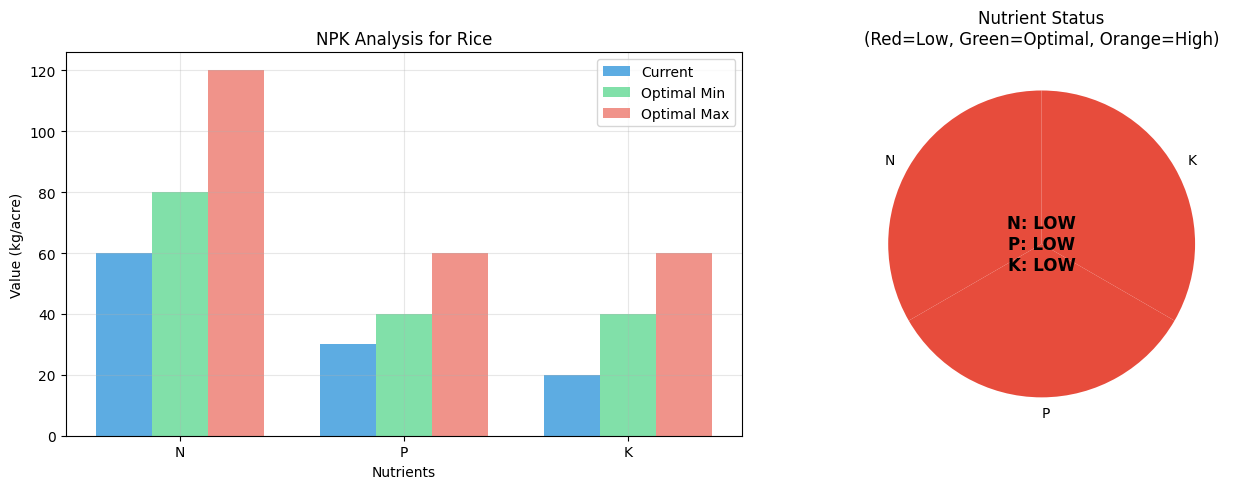

In [5]:
# @title 4. Fertilizer Recommendation System

print("=" * 60)
print("FERTILIZER RECOMMENDATION SYSTEM")
print("=" * 60)

class FertilizerRecommender:
    def __init__(self):
        self.crop_requirements = {
            'rice': {'N': (80, 120), 'P': (40, 60), 'K': (40, 60)},
            'wheat': {'N': (80, 120), 'P': (40, 60), 'K': (40, 60)},
            'maize': {'N': (100, 150), 'P': (50, 70), 'K': (50, 70)},
            'cotton': {'N': (60, 100), 'P': (30, 50), 'K': (30, 50)},
            'sugarcane': {'N': (150, 200), 'P': (60, 80), 'K': (60, 80)},
            'groundnut': {'N': (20, 40), 'P': (40, 60), 'K': (30, 50)},
            'pulses': {'N': (20, 40), 'P': (40, 60), 'K': (20, 40)},
            'vegetables': {'N': (80, 120), 'P': (40, 60), 'K': (60, 80)},
            'fruits': {'N': (100, 150), 'P': (50, 70), 'K': (80, 120)},
            'oilseeds': {'N': (60, 100), 'P': (40, 60), 'K': (40, 60)}
        }

        # Fertilizer database
        self.fertilizers = {
            'low_N': {
                'name': 'Nitrogen Deficiency',
                'message': 'Your soil needs more nitrogen',
                'fertilizers': ['Urea (46-0-0) - 50 kg/acre',
                               'Ammonium Sulfate - 70 kg/acre',
                               'Calcium Ammonium Nitrate - 60 kg/acre'],
                'tips': 'Apply in split doses for better absorption'
            },
            'low_P': {
                'name': 'Phosphorus Deficiency',
                'message': 'Your soil needs more phosphorus',
                'fertilizers': ['Single Super Phosphate (16% P) - 60 kg/acre',
                               'DAP (18-46-0) - 40 kg/acre',
                               'Rock Phosphate - 80 kg/acre'],
                'tips': 'Apply at sowing time for root development'
            },
            'low_K': {
                'name': 'Potassium Deficiency',
                'message': 'Your soil needs more potassium',
                'fertilizers': ['Muriate of Potash (60% K) - 30 kg/acre',
                               'Potassium Sulfate - 35 kg/acre',
                               'Potassium Nitrate - 25 kg/acre'],
                'tips': 'Essential for fruit quality and disease resistance'
            },
            'high_N': {
                'name': 'Excess Nitrogen',
                'message': 'Nitrogen levels are too high',
                'fertilizers': ['Reduce nitrogen application',
                               'Use nitrogen-fixing cover crops',
                               'Apply organic mulch'],
                'tips': 'High nitrogen can lead to excessive vegetative growth'
            },
            'high_P': {
                'name': 'Excess Phosphorus',
                'message': 'Phosphorus levels are too high',
                'fertilizers': ['Avoid phosphorus-rich fertilizers',
                               'Use cover crops to absorb excess P',
                               'Soil testing to monitor levels'],
                'tips': 'Excess P can interfere with the uptake of other nutrients'
            },
            'high_K': {
                'name': 'Excess Potassium',
                'message': 'Potassium levels are too high',
                'fertilizers': ['Avoid potassium-rich fertilizers',
                               'Leach soil with irrigation if possible',
                               'Grow crops that consume a lot of K'],
                'tips': 'High K can lead to deficiencies in magnesium and calcium'
            },
            'balanced': {
                'name': 'Balanced Nutrition',
                'message': 'Your soil has balanced nutrients',
                'fertilizers': ['10-26-26 Complex - 50 kg/acre',
                               '12-32-16 Complex - 45 kg/acre',
                               'Organic compost - 2 tons/acre'],
                'tips': 'Maintain current fertilizer schedule'
            }
        }

    def recommend(self, crop, N, P, K):
        """Generate fertilizer recommendations"""
        req = self.crop_requirements.get(crop.lower(), self.crop_requirements['vegetables'])

        status = {}
        deficits = {}
        recommendations = []

        for nutrient, value, (low, high) in zip(['N', 'P', 'K'], [N, P, K],
                                                [req['N'], req['P'], req['K']]):
            if value < low:
                status[nutrient] = 'low'
                deficits[nutrient] = low - value
                recommendations.append(self.fertilizers[f'low_{nutrient}'])
            elif value > high:
                status[nutrient] = 'high'
                recommendations.append(self.fertilizers[f'high_{nutrient}'])
            else:
                status[nutrient] = 'optimal'

        if not recommendations:
            recommendations.append(self.fertilizers['balanced'])

        # Calculate required NPK ratio
        required_n = max(0, deficits.get('N', 0))
        required_p = max(0, deficits.get('P', 0))
        required_k = max(0, deficits.get('K', 0))

        return {
            'crop': crop,
            'current_npk': {'N': N, 'P': P, 'K': K},
            'status': status,
            'deficits': deficits,
            'recommendations': recommendations,
            'required_ratio': f"{required_n}:{required_p}:{required_k}",
            'priority': [n for n in ['N', 'P', 'K'] if status.get(n) == 'low']
        }

    def visualize(self, crop, N, P, K):
        """Visualize NPK status"""
        result = self.recommend(crop, N, P, K)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        nutrients = ['N', 'P', 'K']
        current = [N, P, K]
        optimal_low = [self.crop_requirements[crop][n][0] for n in nutrients]
        optimal_high = [self.crop_requirements[crop][n][1] for n in nutrients]

        x = np.arange(len(nutrients))
        width = 0.25

        axes[0].bar(x - width, current, width, label='Current', color='#3498db', alpha=0.8)
        axes[0].bar(x, optimal_low, width, label='Optimal Min', color='#2ecc71', alpha=0.6)
        axes[0].bar(x + width, optimal_high, width, label='Optimal Max', color='#e74c3c', alpha=0.6)

        axes[0].set_xlabel('Nutrients')
        axes[0].set_ylabel('Value (kg/acre)')
        axes[0].set_title(f'NPK Analysis for {crop.capitalize()}')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(nutrients)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        colors = {'low': '#e74c3c', 'optimal': '#2ecc71', 'high': '#f39c12'}
        status_colors = [colors[result['status'][n]] for n in nutrients]

        axes[1].pie([1, 1, 1], labels=nutrients, colors=status_colors, autopct=lambda p: '', startangle=90)
        axes[1].set_title('Nutrient Status\n(Red=Low, Green=Optimal, Orange=High)')

        status_text = "\n".join([f"{n}: {result['status'][n].upper()}" for n in nutrients])
        axes[1].text(0, 0, status_text, ha='center', va='center', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.show()

        return result

fertilizer_model = FertilizerRecommender()

print("Testing Fertilizer Recommendations:\n")

test_cases = [
    {'crop': 'rice', 'N': 60, 'P': 30, 'K': 20},
    {'crop': 'wheat', 'N': 100, 'P': 50, 'K': 45},
    {'crop': 'maize', 'N': 180, 'P': 90, 'K': 100},
]

for test in test_cases:
    print(f"\n{'='*50}")
    print(f"Crop: {test['crop'].upper()}")
    print(f"Current NPK: N={test['N']}, P={test['P']}, K={test['K']}")

    result = fertilizer_model.recommend(test['crop'], test['N'], test['P'], test['K'])

    print("\n📊 Status:")
    for n, s in result['status'].items():
        print(f"  {n}: {s}")

    print("\n💡 Recommendations:")
    for rec in result['recommendations'][:2]:
        print(f"  • {rec['name']}")
        print(f"    {rec['message']}")
        print(f"    Fertilizers: {', '.join(rec['fertilizers'][:2])}")

print("\n" + "="*50)
print("Visualizing NPK Status for Rice (N=60, P=30, K=20)")
result = fertilizer_model.visualize('rice', 60, 30, 20)

PLANT DISEASE DETECTION CNN

🚀 Starting training...
Loading and preprocessing images...
Found 112 images belonging to 2 classes.
Found 28 images belonging to 2 classes.

📊 Dataset Info:
Classes: ['train', 'validation']
Training samples: 112
Validation samples: 28

🔄 Creating model...

🔄 Training model...
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5875 - loss: 1.9718 - val_accuracy: 0.7143 - val_loss: 0.6028
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.6250 - loss: 0.7194 - val_accuracy: 0.7143 - val_loss: 0.6159
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.6625 - loss: 0.6719 - val_accuracy: 0.7143 - val_loss: 0.6646
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.8438 - loss: 0.5946 - val_accuracy: 0.7143 - val_loss: 0.6691
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7396 - loss: 0.6226 - val_accuracy: 0.7143 - val_loss: 0.6581


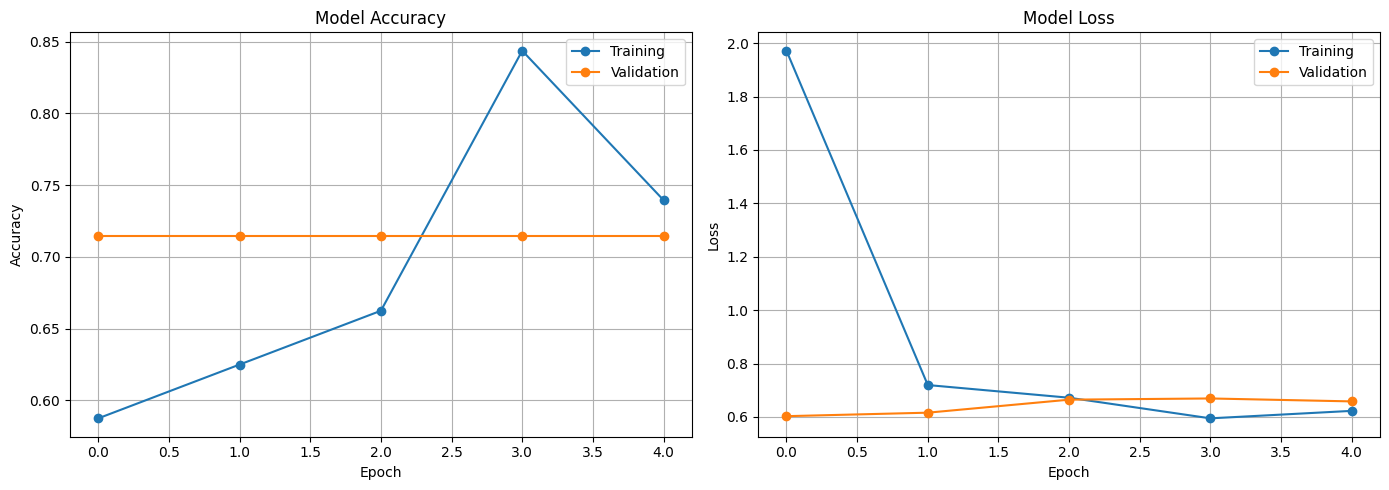


🎯 Final Validation Accuracy: 0.7143
✅ Model saved to 'models/' directory

🔍 Testing Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


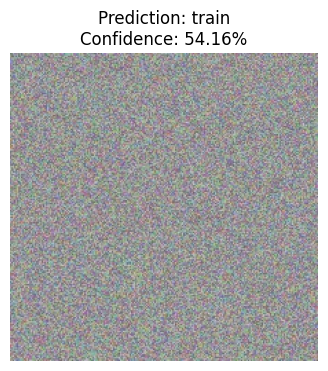


Prediction: train
Confidence: 54.16%


In [6]:
# @title 5. Plant Disease Detection CNN

print("=" * 60)
print("PLANT DISEASE DETECTION CNN")
print("=" * 60)

class PlantDiseaseDetector:
    def __init__(self, img_size=128):
        self.img_size = img_size
        self.model = None
        self.class_names = ['healthy', 'diseased']  # Default classes

    def create_model(self):
        """Create a simple CNN model"""
        model = models.Sequential([
            # First convolutional block
            layers.Conv2D(32, (3,3), activation='relu', input_shape=(self.img_size, self.img_size, 3)),
            layers.MaxPooling2D(2,2),
            layers.Dropout(0.25),

            # Second convolutional block
            layers.Conv2D(64, (3,3), activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Dropout(0.25),

            # Third convolutional block
            layers.Conv2D(128, (3,3), activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Dropout(0.25),

            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(2, activation='softmax')  # 2 classes: healthy, diseased
        ])

        return model

    def train(self, data_dir, epochs=10):
        """Train the model"""
        print("Loading and preprocessing images...")

        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            validation_split=0.2
        )

        train_generator = train_datagen.flow_from_directory(
            data_dir,
            target_size=(self.img_size, self.img_size),
            batch_size=32,
            class_mode='categorical',
            subset='training'
        )

        validation_generator = train_datagen.flow_from_directory(
            data_dir,
            target_size=(self.img_size, self.img_size),
            batch_size=32,
            class_mode='categorical',
            subset='validation'
        )

        self.class_names = list(train_generator.class_indices.keys())

        print(f"\n📊 Dataset Info:")
        print(f"Classes: {self.class_names}")
        print(f"Training samples: {train_generator.samples}")
        print(f"Validation samples: {validation_generator.samples}")

        print("\n🔄 Creating model...")
        self.model = self.create_model()
        self.model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        print("\n🔄 Training model...")
        history = self.model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // 32,
            epochs=epochs,
            validation_data=validation_generator,
            validation_steps=validation_generator.samples // 32,
            verbose=1
        )

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(history.history['accuracy'], label='Training', marker='o')
        axes[0].plot(history.history['val_accuracy'], label='Validation', marker='o')
        axes[0].set_title('Model Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(history.history['loss'], label='Training', marker='o')
        axes[1].plot(history.history['val_loss'], label='Validation', marker='o')
        axes[1].set_title('Model Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

        val_acc = history.history['val_accuracy'][-1]
        print(f"\n🎯 Final Validation Accuracy: {val_acc:.4f}")

        return history

    def predict(self, image_path):
        """Predict disease from image"""
        if self.model is None:
            return {'error': 'Model not trained'}

        # Load and preprocess image
        img = Image.open(image_path)
        img = img.resize((self.img_size, self.img_size))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = self.model.predict(img_array)[0]

        pred_class = self.class_names[np.argmax(predictions)]
        confidence = predictions[np.argmax(predictions)]

        plt.figure(figsize=(6, 4))
        plt.imshow(Image.open(image_path))
        plt.title(f'Prediction: {pred_class}\nConfidence: {confidence:.2%}')
        plt.axis('off')
        plt.show()

        return {
            'class': pred_class,
            'confidence': f"{confidence:.2%}",
            'probabilities': {
                self.class_names[i]: f"{predictions[i]:.2%}"
                for i in range(len(self.class_names))
            }
        }

    def save_model(self):
        """Save model"""
        if self.model:
            self.model.save('models/disease_model.h5')
            joblib.dump(self.class_names, 'models/disease_classes.pkl')
            print("✅ Model saved to 'models/' directory")

print("\n🚀 Starting training...")
disease_model = PlantDiseaseDetector(img_size=128)
history = disease_model.train('datasets/plant_disease', epochs=5)
disease_model.save_model()


print("\n🔍 Testing Prediction:")

test_img_path = 'datasets/plant_disease/validation/healthy/sample_0.jpg'
if os.path.exists(test_img_path):
    result = disease_model.predict(test_img_path)
    print(f"\nPrediction: {result['class']}")
    print(f"Confidence: {result['confidence']}")

In [ ]:
# @title 6. Interactive Web Interface with Gradio

print("=" * 60)
print("INTERACTIVE WEB INTERFACE")
print("=" * 60)

!pip install -q gradio

import gradio as gr


print("Loading models...")


crop_model = CropRecommendationModel()
try:
    crop_model.scaler = joblib.load('models/crop_scaler.pkl')
    crop_model.label_encoder = joblib.load('models/crop_encoder.pkl')
    crop_model.models = joblib.load('models/crop_models.pkl')
    crop_model.ensemble_weights = joblib.load('models/crop_weights.pkl')
    crop_model.classes_ = joblib.load('models/crop_classes.pkl')
    print("✅ Crop model loaded")
except:
    print("⚠️ Crop model not found, using trained instance")


disease_model = PlantDiseaseDetector()
try:
    disease_model.model = keras.models.load_model('models/disease_model.h5')
    disease_model.class_names = joblib.load('models/disease_classes.pkl')
    print("✅ Disease model loaded")
except:
    print("⚠️ Disease model not found, using trained instance")


def crop_recommendation_interface(N, P, K, temp, humidity, ph, rainfall):
    """Crop recommendation interface"""
    features = [N, P, K, temp, humidity, ph, rainfall]
    result = crop_model.predict(features)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


    features_names = ['N', 'P', 'K', 'Temp', 'Humidity', 'pH', 'Rainfall']
    values = [N, P, K, temp, humidity, ph, rainfall]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']

    bars = ax1.bar(features_names, values, color=colors)
    ax1.set_title('Input Soil Parameters')
    ax1.set_ylabel('Value')
    ax1.grid(True, alpha=0.3)


    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)


    crops = [r['crop'] for r in result['top_3']]
    confidences = [float(r['confidence'].replace('%', '')) for r in result['top_3']]

    wedges, texts, autotexts = ax2.pie(confidences, labels=crops, autopct='%1.1f%%',
                                        colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax2.set_title('Top 3 Crop Recommendations')

    plt.tight_layout()


    plt.savefig('crop_result.png', bbox_inches='tight')
    plt.close()


    result_text = f"## 🌾 Primary Recommendation: {result['primary_crop']}\n"
    result_text += f"### Confidence: {result['primary_confidence']}\n\n"
    result_text += "### 📋 Top 3 Recommendations:\n"
    for i, rec in enumerate(result['top_3'], 1):
        result_text += f"{i}. **{rec['crop']}** - {rec['confidence']}\n"

    return result_text, 'crop_result.png'

def fertilizer_interface(crop, N, P, K):
    """Fertilizer recommendation interface"""
    result = fertilizer_model.visualize(crop, N, P, K)

    rec_text = f"## 🌱 Fertilizer Recommendations for {crop.capitalize()}\n\n"
    rec_text += f"### Current NPK: N={N}, P={P}, K={K}\n\n"

    rec_text += "### 📊 Nutrient Status:\n"
    for n, s in result['status'].items():
        emoji = "✅" if s == 'optimal' else "⚠️" if s == 'low' else "📈"
        rec_text += f"{emoji} **{n}**: {s.upper()}\n"

    rec_text += "\n### 💡 Recommendations:\n"
    for rec in result['recommendations']:
        rec_text += f"\n**{rec['name']}**\n"
        rec_text += f"_{rec['message']}_\n"
        rec_text += f"• Fertilizers: {', '.join(rec['fertilizers'][:2])}\n"
        if 'tips' in rec:
            rec_text += f"• Tip: {rec['tips']}\n"

    if result['priority']:
        rec_text += f"\n### ⚡ Priority Nutrients: {', '.join(result['priority'])}\n"

    plt.savefig('fertilizer_result.png', bbox_inches='tight')
    plt.close()

    return rec_text, 'fertilizer_result.png'

def disease_interface(image):
    """Plant disease detection interface"""
    if image is None:
        return "Please upload an image", None

    image_path = 'temp_image.jpg'
    image.save(image_path)

    result = disease_model.predict(image_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Display the uploaded image
    ax1.imshow(Image.open(image_path))
    ax1.set_title('Uploaded Image')
    ax1.axis('off')

    # Display prediction probabilities
    classes = list(result['probabilities'].keys())
    confidences = [float(result['probabilities'][c].replace('%', '')) for c in classes]

    bars = ax2.bar(classes, confidences, color=['#4ECDC4', '#FF6B6B'])
    ax2.set_title('Prediction Probabilities')
    ax2.set_ylabel('Confidence (%)')
    ax2.set_ylim(0, 100)
    for bar, conf in zip(bars, confidences):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{conf:.1f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('disease_result.png', bbox_inches='tight')
    plt.close()

    result_text = f"## 🌱 Disease Detection Result:\n\n"
    result_text += f"### Predicted Class: **{result['class']}**\n"
    result_text += f"### Confidence: {result['confidence']}\n\n"
    result_text += "### All Probabilities:\n"
    for cls, prob in result['probabilities'].items():
        result_text += f"- {cls.capitalize()}: {prob}\n"

    return result_text, 'disease_result.png'

# Create Gradio interfaces
with gr.Blocks() as demo:
    gr.Markdown("# 🌱 Smart Agriculture Platform 🌾")
    gr.Markdown("This platform offers Crop Recommendation, Fertilizer Recommendation, and Plant Disease Detection.")

    with gr.Tab("Crop Recommendation"):
        gr.Markdown("## Crop Recommendation System")
        gr.Markdown("Enter your soil and environmental parameters to get crop suggestions.")
        with gr.Row():
            N = gr.Slider(minimum=0, maximum=200, value=90, label="Nitrogen (N)")
            P = gr.Slider(minimum=0, maximum=150, value=42, label="Phosphorus (P)")
            K = gr.Slider(minimum=0, maximum=150, value=43, label="Potassium (K)")
        with gr.Row():
            temp = gr.Slider(minimum=0, maximum=50, value=22.5, label="Temperature (°C)")
            humidity = gr.Slider(minimum=0, maximum=100, value=80, label="Humidity (%)")
            ph = gr.Slider(minimum=0, maximum=14, value=6.5, label="pH Value")
            rainfall = gr.Slider(minimum=0, maximum=300, value=200, label="Rainfall (mm)")
        crop_output_text = gr.Markdown()
        crop_output_image = gr.Image(type="filepath", label="Recommendation Visuals")
        crop_btn = gr.Button("Get Crop Recommendation")
        crop_btn.click(crop_recommendation_interface,
                       inputs=[N, P, K, temp, humidity, ph, rainfall],
                       outputs=[crop_output_text, crop_output_image])

    with gr.Tab("Fertilizer Recommendation"):
        gr.Markdown("## Fertilizer Recommendation System")
        gr.Markdown("Select your crop and provide NPK values to get fertilizer advice.")
        with gr.Row():
            f_crop = gr.Dropdown(choices=crop_model.classes_.tolist(), label="Select Crop", value='rice')
            f_N = gr.Slider(minimum=0, maximum=200, value=60, label="Nitrogen (N)")
            f_P = gr.Slider(minimum=0, maximum=150, value=30, label="Phosphorus (P)")
            f_K = gr.Slider(minimum=0, maximum=150, value=20, label="Potassium (K)")
        fert_output_text = gr.Markdown()
        fert_output_image = gr.Image(type="filepath", label="NPK Analysis Visuals")
        fert_btn = gr.Button("Get Fertilizer Recommendation")
        fert_btn.click(fertilizer_interface,
                       inputs=[f_crop, f_N, f_P, f_K],
                       outputs=[fert_output_text, fert_output_image])

    with gr.Tab("Plant Disease Detection"):
        gr.Markdown("## Plant Disease Detection")
        gr.Markdown("Upload an image of a plant leaf to detect potential diseases.")
        disease_input_image = gr.Image(type="pil", label="Upload Leaf Image")
        disease_output_text = gr.Markdown()
        disease_output_image = gr.Image(type="filepath", label="Prediction Visuals")
        disease_btn = gr.Button("Detect Disease")
        disease_btn.click(disease_interface,
                          inputs=disease_input_image,
                          outputs=[disease_output_text, disease_output_image])

# Launch the Gradio app
print("\n🚀 Launching Gradio interface...")
demo.launch(debug=True, share=True)

INTERACTIVE WEB INTERFACE
Loading models...
✅ Crop model loaded


✅ Disease model loaded

🚀 Launching Gradio interface...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e6f0d456f555b944b4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
